# Doc2Vec

## Definition
Doc2Vec (also called Paragraph Vectors) is an extension of Word2Vec that learns fixed-length vector representations for variable-length text units such as sentences, paragraphs, or entire documents. Introduced by Le and Mikolov (2014), it adds a unique document ID vector to the Word2Vec training process, allowing the model to capture document-level semantics beyond individual word meanings.

## Why It Is Needed
- **Document-Level Representation:** Word2Vec produces word vectors; Doc2Vec extends this to produce a single vector for an entire document, paragraph, or sentence.
- **Order Sensitivity:** Unlike Bag-of-Words, Doc2Vec considers word order and context within a document.
- **Unsupervised Learning:** Learns document representations without requiring labeled data.

## Real-World Applications
- Document similarity and clustering in information retrieval
- Finding similar news articles, research papers, or blog posts
- Document classification using learned document vectors as features
- Sentiment analysis at the document or review level
- Semantic search over document collections

## Important Points
- **Two Architectures:**
  - **PV-DM (Distributed Memory):** Analogous to CBOW — predicts the next word using both context words and the paragraph vector. Recommended for most tasks.
  - **PV-DBOW (Distributed Bag of Words):** Analogous to Skip-gram — predicts context words from the paragraph vector alone, ignoring word order.
- **Paragraph Vector:** A unique, trainable vector assigned to each document during training — acts as a memory of document context.
- **Inference for New Documents:** Doc2Vec requires running additional training iterations (`model.infer_vector()`) to compute a vector for unseen documents.
- **Gensim `Doc2Vec`:** Standard Python implementation; takes `TaggedDocument` objects as input.
- Doc2Vec outperforms simple averaging of Word2Vec vectors for document-level tasks.

## Visual Understanding
```
[Insert architecture diagram of PV-DM showing:
 [Paragraph ID Vector] + [Context Word Vectors] → Concatenate/Average → Predict next word]
```

## Implementation
Practical implementation will be added here.

## Key Takeaways
- Doc2Vec extends Word2Vec to produce fixed-length vectors for entire documents.
- PV-DM (with memory) generally outperforms PV-DBOW for most NLP tasks.
- A unique paragraph vector is trained for each document in the corpus.
- `model.infer_vector()` is used to generate vectors for new, unseen documents.
- Doc2Vec captures word order and context, unlike Bag-of-Words representations.

In [ ]:
# 3-D Doc2Vec

Vector for ['deep', 'learning']: [-4.5524477e-03 -9.6064908e-03  2.3893286e-03  9.3255844e-03
 -1.2131477e-03  6.4082263e-04  5.0379373e-03 -4.0874863e-03
 -5.2471720e-03 -4.2174561e-03 -9.5047290e-03 -6.0915444e-03
 -4.2395489e-03 -9.2279352e-03 -3.1772465e-03 -2.8234357e-03
  9.3225632e-03  1.0640502e-04  2.0241654e-03  8.8549256e-03
  7.1161366e-03 -3.1136824e-03 -3.3145165e-03 -9.1250082e-03
  9.7999575e-05  5.4650186e-03  3.4942650e-03 -4.2520189e-03
 -4.5541208e-03  7.2460365e-03  5.0686393e-03  9.1096731e-03
 -4.4960394e-03 -3.5287917e-03 -8.0133071e-03 -3.6545319e-03
  6.8417978e-03 -2.7480447e-03  5.1999651e-03  3.5743737e-03
 -8.9462101e-04  5.7550929e-03  4.2806389e-03 -6.6369353e-04
  9.5869862e-03 -4.9061822e-03 -8.7364484e-03 -4.1303770e-03
 -9.3080821e-03  3.6703467e-03]


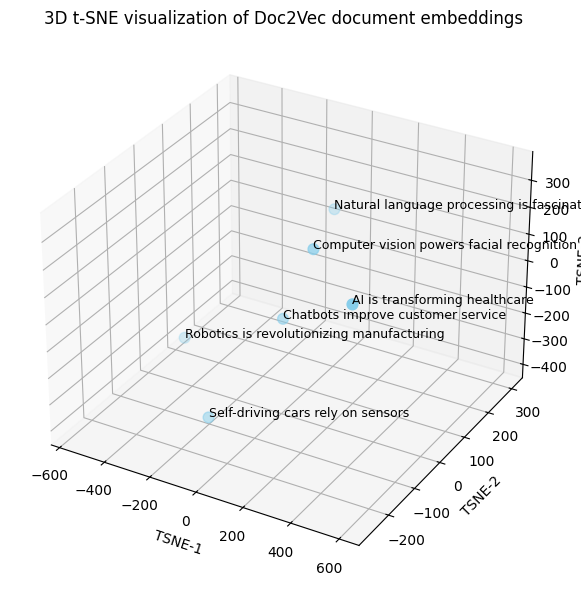

In [1]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Example Corpus
data = [
    "AI is transforming healthcare",
    "Natural language processing is fascinating",
    "Self-driving cars rely on sensors",
    "Chatbots improve customer service",
    "Computer vision powers facial recognition",
    "Robotics is revolutionizing manufacturing"
]

# Tagging documents
tagged_data = [TaggedDocument(words=d.split(), tags=[str(i)]) for i, d in enumerate(data)]

# Training
model = Doc2Vec(vector_size=50, window=2, min_count=1, workers=4, epochs=40)
model.build_vocab(tagged_data)
model.train(tagged_data, total_examples=model.corpus_count, epochs=model.epochs)

# Inference
vec = model.infer_vector(["deep", "learning"])
print("Vector for ['deep', 'learning']:", vec)

# Get document vectors as a NumPy array
vectors = np.array([model.dv[str(i)] for i in range(len(tagged_data))])

# 3D t-SNE Visualization
tsne = TSNE(n_components=3, random_state=42, perplexity=2)
reduced = tsne.fit_transform(vectors)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2], c='skyblue', s=60)

for i, txt in enumerate(data):
    ax.text(reduced[i, 0], reduced[i, 1], reduced[i, 2], txt, fontsize=9)

ax.set_title("3D t-SNE visualization of Doc2Vec document embeddings")
ax.set_xlabel("TSNE-1")
ax.set_ylabel("TSNE-2")
ax.set_zlabel("TSNE-3")
plt.tight_layout()
plt.show()

## Sentiment Classification


In [3]:
import gensim.downloader as api
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import numpy as np
import re

# Step 1: Load Pre-trained Word Embeddings
print("⏳ Loading GloVe embeddings...")
word_vectors = api.load("glove-wiki-gigaword-50")
print("✅ Loaded.")

# Step 2: Extended Data (text, sentiment)
data = [
    ("I loved the movie, it was fantastic!", "positive"),
    ("The movie was okay, not the best.", "neutral"),
    ("Terrible movie. Wouldn’t recommend.", "negative"),
    ("Really enjoyed the characters and plot.", "positive"),
    ("It was boring and predictable.", "negative"),
    ("An average film, not too bad.", "neutral"),
    ("What a masterpiece, absolutely loved it!", "positive"),
    ("Poor acting and bad script. Waste of time.", "negative"),
    ("Nothing special, just another average film.", "neutral"),
    ("Incredible visuals and emotional story.", "positive"),
    ("Couldn't even finish it. So bad.", "negative"),
    ("Neither good nor bad. Just meh.", "neutral"),
    ("Brilliant performance by the lead actor!", "positive"),
    ("The plot was weak and unoriginal.", "negative"),
    ("Mediocre at best, not memorable.", "neutral"),
    ("Exceeded my expectations. A must-watch!", "positive"),
    ("The direction was sloppy and confusing.", "negative"),
    ("Some parts were good, others not so much.", "neutral")
]

# Step 3: Preprocessing and Sentence Vectorization
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

def sentence_vector(sentence):
    words = preprocess(sentence)
    vectors = [word_vectors[word] for word in words if word in word_vectors]
    if not vectors:
        return np.zeros(word_vectors.vector_size)
    return np.mean(vectors, axis=0)

# Step 4: Create Training Data
X = [sentence_vector(text) for text, _ in data]
y = [label for _, label in data]

# Step 5: Train Classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

# Step 6: Predict New Review
new_review = "The plot was weak and unoriginal"
new_vec = sentence_vector(new_review)
predicted_label = clf.predict([new_vec])[0]
print(f"\n🔍 Predicted Sentiment for Review: \"{new_review}\" → {predicted_label}")

⏳ Loading GloVe embeddings...
✅ Loaded.

🔍 Predicted Sentiment for Review: "The plot was weak and unoriginal" → negative


## Semantic Search

In [4]:
import gensim.downloader as api
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re

# ✅ Load pre-trained GloVe embeddings (50d for speed)
print("⏳ Loading pre-trained GloVe...")
word_vectors = api.load("glove-wiki-gigaword-50")
print("✅ Loaded GloVe embeddings.")

# Sample corpus of reviews
data = [
    "I loved the movie, it was fantastic!",
    "The movie was okay, not the best.",
    "Terrible movie. Wouldn’t recommend.",
    "Really enjoyed the characters and plot.",
    "It was boring and predictable.",
    "An average film, not too bad.",
    "What a masterpiece, absolutely loved it!",
    "Poor acting and bad script. Waste of time.",
    "Nothing special, just another average film.",
    "Incredible visuals and emotional story.",
    "Couldn't even finish it. So bad.",
    "Neither good nor bad. Just meh.",
    "Brilliant performance by the lead actor!",
    "The plot was weak and unoriginal.",
    "Mediocre at best, not memorable.",
    "Exceeded my expectations. A must-watch!",
    "The direction was sloppy and confusing.",
    "Some parts were good, others not so much."
]

# Preprocessing function
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

# Function to get sentence embedding
def sentence_vector(sentence):
    words = preprocess(sentence)
    vectors = [word_vectors[word] for word in words if word in word_vectors]
    if not vectors:
        return np.zeros(word_vectors.vector_size)
    return np.mean(vectors, axis=0)

# Precompute document embeddings
doc_vectors = np.array([sentence_vector(doc) for doc in data])

# Semantic search
def semantic_search(query, top_n=3):
    query_vec = sentence_vector(query)
    similarities = cosine_similarity([query_vec], doc_vectors)[0]
    top_indices = similarities.argsort()[::-1][:top_n]

    print(f"\n🔍 Query: \"{query}\"")
    print(f"\nTop {top_n} most similar reviews:")
    for idx in top_indices:
        print(f"→ ({similarities[idx]:.2f}) {data[idx]}")

# Example
semantic_search("A deeply emotional film with stunning visuals")

⏳ Loading pre-trained GloVe...
✅ Loaded GloVe embeddings.

🔍 Query: "A deeply emotional film with stunning visuals"

Top 3 most similar reviews:
→ (0.94) Incredible visuals and emotional story.
→ (0.89) Really enjoyed the characters and plot.
→ (0.89) Brilliant performance by the lead actor!


# Document Rating

In [5]:
import gensim.downloader as api
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np
import re

# Step 1: Load GloVe vectors (no external file needed)
print("⏳ Loading GloVe embeddings...")
word_vectors = api.load("glove-wiki-gigaword-50")
print("✅ Loaded GloVe embeddings.")

# Step 2: Sample data (text, sentiment, score)
data = [
    ("I loved the movie, it was fantastic!", "positive", 4.5),
    ("The movie was okay, not the best.", "neutral", 3.0),
    ("Terrible movie. Wouldn’t recommend.", "negative", 1.2),
    ("Really enjoyed the characters and plot.", "positive", 4.7),
    ("It was boring and predictable.", "negative", 2.0),
    ("An average film, not too bad.", "neutral", 3.2)
]

# Step 3: Preprocessing and vectorization
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

def sentence_vector(text):
    words = preprocess(text)
    vectors = [word_vectors[word] for word in words if word in word_vectors]
    if not vectors:
        return np.zeros(word_vectors.vector_size)
    return np.mean(vectors, axis=0)

# Step 4: Vectorize training data
X = [sentence_vector(text) for text, _, _ in data]
y = [score for _, _, score in data]

# Step 5: Train Ridge Regression
reg = Ridge()
reg.fit(X, y)

# Step 6: Predict and Evaluate on training
y_pred = reg.predict(X)
mse = mean_squared_error(y, y_pred)
print(f"\n📉 MSE on training data: {mse:.3f}")

# 🔮 Step 7: Predict Rating for a New Review
new_review = "This movie was absolutely thrilling and emotional"
new_vec = sentence_vector(new_review)
predicted_score = reg.predict([new_vec])[0]
print(f"\n⭐ Predicted Score for Review: \"{new_review}\" → {predicted_score:.2f}")

⏳ Loading GloVe embeddings...
✅ Loaded GloVe embeddings.

📉 MSE on training data: 0.186

⭐ Predicted Score for Review: "This movie was absolutely thrilling and emotional" → 3.53
